##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
!pip install -q keras-cv tensorflow pillow matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 31.4 MB/s eta 0:00:00


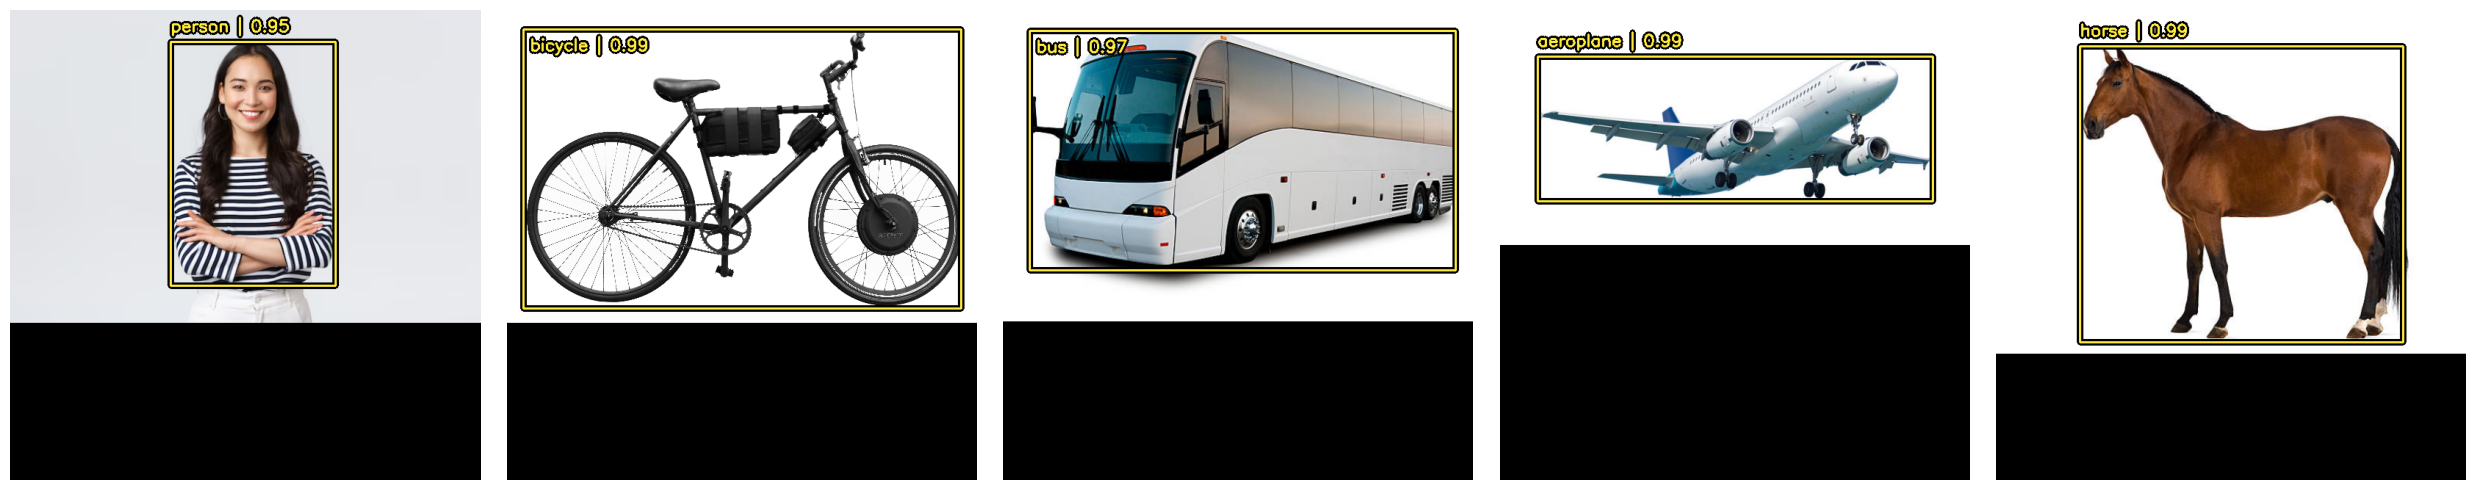

,Image,Expected (VOC),Top Predicted Labels,"Top-1 (label, conf)",Correct?,Notes (missed/wrong)
0,person,person,person,person (94.86%),Yes,OK
1,bicycle,bicycle,bicycle,bicycle (98.88%),Yes,OK
2,bus,bus,bus,bus (96.90%),Yes,OK
3,aeroplane,aeroplane,aeroplane,aeroplane (98.61%),Yes,OK
4,horse,horse,horse,horse (99.39%),Yes,OK


In [2]:
import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# 1) Load YOLOv8 model (Pascal VOC preset)
detector = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

# 2) Resizing layer
inference_resizing = keras_cv.layers.Resizing(
    640, 640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh"
)

# 3) Pascal VOC class mapping
class_mapping = {
    0: "aeroplane", 1: "bicycle", 2: "bird", 3: "boat", 4: "bottle",
    5: "bus", 6: "car", 7: "cat", 8: "chair", 9: "cow",
    10: "diningtable", 11: "dog", 12: "horse", 13: "motorbike", 14: "person",
    15: "pottedplant", 16: "sheep", 17: "sofa", 18: "train", 19: "tvmonitor"
}


samples = [
    {"path": "/content/person",   "expected": ["person"]},
    {"path": "/content/bicycle",  "expected": ["bicycle"]},
    {"path": "/content/bus",      "expected": ["bus"]},
    {"path": "/content/aeroplane","expected": ["aeroplane"]},
    {"path": "/content/horse",    "expected": ["horse"]},
]

def load_rgb(path: str) -> np.ndarray:
    """Load image as RGB uint8 numpy array."""
    img = Image.open(path).convert("RGB")
    return np.array(img, dtype=np.uint8)

def resize_for_inference(img_np: np.ndarray) -> np.ndarray:
    """Resize to 640x640 with padding while keeping bbox format consistent."""
    resized = inference_resizing(tf.expand_dims(img_np, 0))[0]
    return resized.numpy()

def top_detections(pred, k=5):
    """Return top-k detections (label, confidence) sorted by confidence."""
    classes = pred["classes"].astype(int)
    confs = pred["confidence"]
    valid = confs > 0
    classes = classes[valid]
    confs = confs[valid]

    order = np.argsort(-confs)[:k]
    out = []
    for idx in order:
        cls_id = int(classes[idx])
        out.append((class_mapping.get(cls_id, str(cls_id)), float(confs[idx])))
    return out

# 5) Load + resize images
imgs = [load_rgb(s["path"]) for s in samples]
imgs_resized = np.stack([resize_for_inference(img) for img in imgs], axis=0)

# 6) Run inference
predictions = detector.predict(imgs_resized, verbose=0)

# 7) Visualize detections
keras_cv.visualization.plot_bounding_box_gallery(
    imgs_resized,
    value_range=(0, 255),
    rows=1,
    cols=5,
    y_pred=predictions,
    scale=5,
    font_scale=0.75,
    bounding_box_format="xywh",
    class_mapping=class_mapping
)
plt.show()

# 8) Record results (correct / missed / wrong labels)
rows = []
for i, s in enumerate(samples):
    pred_i = {k: predictions[k][i] for k in predictions.keys()}
    top5 = top_detections(pred_i, k=5)

    # predicted labels present (unique)
    predicted_labels = sorted({lbl for lbl, _ in top5})
    expected = [e.lower() for e in s["expected"]]

    # simple correctness: expected label appears in predictions
    correct = any(e in [p.lower() for p in predicted_labels] for e in expected)

    rows.append({
        "Image": s["path"].split("/")[-1],
        "Expected (VOC)": ", ".join(s["expected"]),
        "Top Predicted Labels": ", ".join(predicted_labels) if predicted_labels else "None",
        "Top-1 (label, conf)": f"{top5[0][0]} ({top5[0][1]*100:.2f}%)" if top5 else "None",
        "Correct?": "Yes" if correct else "No",
        "Notes (missed/wrong)": "OK" if correct else "Missed expected label / wrong label"
    })

results_df = pd.DataFrame(rows)
results_df